# Teste 1 - Inteligência Artificial

## Etapa 1 - Carregar os dados

In [36]:
import pandas as pd

dados = pd.read_csv("base_credito.csv")

dados

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54
...,...,...,...,...,...
49995,38,8818.70,760,94.72,47301.48
49996,55,11501.96,728,75.57,50408.79
49997,46,7374.09,479,91.25,22142.20
49998,29,2290.91,739,95.07,24040.33


## Etapa 2 - Conhecer os dados

As variáveis utilizadas como entrada são:

- **idade:** idade do cliente;
- **renda_mensal:** renda mensal do cliente;
- **score_credito:** pontuação de crédito do cliente;
- **historico_pagamentos:** indicador do histórico de pagamentos do cliente.

A variável que será prevista é:

- **valor_emprestimo:** valor do empréstimo aprovado para o cliente.

As variáveis idade e score_credito sao do tipo inteiro. Já renda_mensal, historico_pagamentos e valor_emprestimo são do tipo decimal.

In [37]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB


In [38]:
dados.describe()

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,40.08028,7542.184144,649.581780,81.836888,31736.158491
std,10.77612,4524.255313,84.648363,11.209708,14456.325322
min,18.00000,1500.000000,300.000000,16.210000,1000.000000
25%,33.00000,4463.347500,592.000000,75.160000,22018.212500
50%,40.00000,6452.295000,650.000000,83.720000,29039.420000
75%,47.00000,9395.700000,707.000000,90.330000,38275.932500
max,70.00000,50000.000000,850.000000,100.000000,150000.000000


## Etapa 3 - Analisar os dados

Para realizar uma análise inicial, sera´ observada a relação entre a renda mensal do cliente e o valor do empréstimo aprovado.

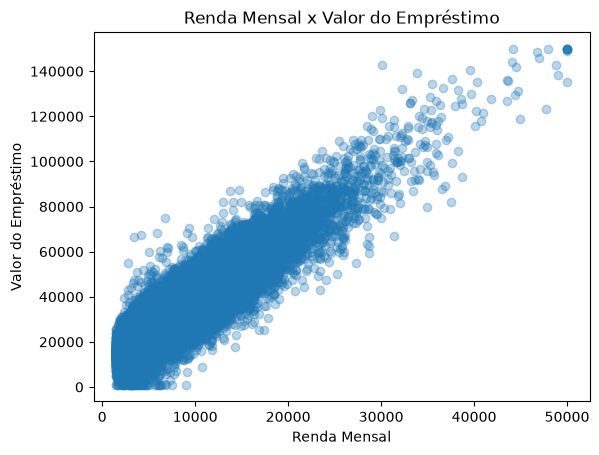

In [39]:
import matplotlib.pyplot as plt

plt.scatter(dados["renda_mensal"], dados["valor_emprestimo"], alpha=0.3)
plt.xlabel("Renda Mensal")
plt.ylabel("Valor do Empréstimo")
plt.title("Renda Mensal x Valor do Empréstimo")
plt.show()

### Análise do gráfico

Observando o gráfico, é possível perceber uma relação positiva entre a renda mensal e o valor do empréstimo. De modo geral, clientes que possuem uma renda mensal maior tendem a receber valores maiores de empréstimo.

Apesar dessa tendência, os pontos não formam uma linha perfeita, indicando que outras características do cliente também influenciam o valor aprovado.

## Etapa 4 - Preparar os dados

Os dados foram divididos em dois conjuntos:

- **80% para treinamento**
- **20% para teste**

As variáveis idade, renda mensal, score de crédito e histórico de pagamentos serão utilizadas como entrada. O valor do empréstimo será a variável que o modelo deverá prever.

In [40]:
from sklearn.model_selection import train_test_split

X = dados[["idade", "renda_mensal", "score_credito", "historico_pagamentos"]]
y = dados["valor_emprestimo"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
print("Quantidade para treinamento:", len(X_treino))
print("Quantidade para teste:", len(X_teste))

Quantidade para treinamento: 40000
Quantidade para teste: 10000


## Etapa 5 - Treinar o modelo

Foi utilizado o algoritmo de Regressão Linear para construir o modelo e realizar as previsões dos valores dos empréstimos.

In [42]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_treino, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[54.71, 2.83,60.89,98.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['idade','renda_mensal','score_credito','historico_pagamentos']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.944e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [43]:
previsoes = modelo.predict(X_teste)

previsoes

array([14806.33565684, 29512.49287915, 25840.73554724, ...,
       37098.02961436, 34521.68648516, 42404.37788797], shape=(10000,))

## Etapa 6 - Avaliar o modelo

Para avaliar o modelo serão utilizadas as métricas MAE e R².

O MAE representa a diferença média entre os valores previstos e os valores reais.

O R² indica quanto da variação dos valores dos empréstimos consegue ser explicada pelo modelo.

In [44]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_teste, previsoes)
r2 = r2_score(y_teste, previsoes)

print("MAE:", round(mae, 2))
print("R²:", round(r2, 4))

MAE: 2985.94
R²: 0.9223


### Análise das métricas

O MAE encontrado foi de aproximadamente R$ 2.985,94. Isso significa que, em média, as previsões realizadas pelo modelo apresentam uma diferença de aproximadamente R$ 2.985,94 em relação aos valores reais.

O R² foi de aproximadamente 0,9223. Isso indica que o modelo consegue explicar cerca de 92,23% da variação presente nos valores dos empréstimos.

Os resultados mostram que o modelo conseguiu identificar grande parte da relação entre as características dos clientes e os valores dos empréstimos.

## Etapa 7 - Comparar valores reais e previstos

Nesta etapa serão comparados os valores reais dos empréstimos com os valores previstos pelo modelo.

In [45]:
comparacao = pd.DataFrame({
    "Valor Real": y_teste.values,
    "Valor Previsto": previsoes
})

comparacao.head(10)

,Valor Real,Valor Previsto
0,22268.46,14806.335657
1,27457.59,29512.492879
2,25451.04,25840.735547
3,23890.67,21077.522905
4,27754.95,27919.314046
5,12544.92,14530.910394
6,28759.01,27385.966936
7,46454.49,41011.609092
8,43199.01,36525.087756
9,34051.39,35786.960945


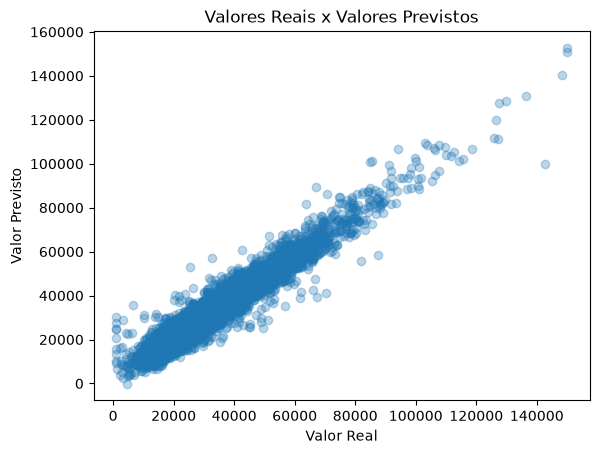

In [46]:
plt.scatter(y_teste, previsoes, alpha=0.3)
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Valores Reais x Valores Previstos")
plt.show()

### Análise da comparação

Ao comparar os valores reais com os valores previstos, é possível observar que muitas das previsões ficam próximas dos valores reais.

Entretanto, existem casos em que a diferença é maior. Isso ocorre porque o modelo realiza estimativas e não consegue representar perfeitamente todos os casos presentes na base.

De maneira geral, os resultados indicam que o modelo conseguiu representar boa parte do comportamento dos dados.

## Etapa 8 - Fazer uma previsão

Foi criado um novo cliente com as seguintes características:

- **Idade:** 35 anos
- **Renda mensal:** R$ 8.000,00
- **Score de crédito:** 700
- **Histórico de pagamentos:** 85

In [47]:
novo_cliente = pd.DataFrame({
    "idade": [35],
    "renda_mensal": [8000],
    "score_credito": [700],
    "historico_pagamentos": [85]
})

valor_previsto = modelo.predict(novo_cliente)

print("Valor previsto: R$", round(valor_previsto[0], 2))

Valor previsto: R$ 36133.12


### Interpretação

Com base nas características informadas, o modelo estimou um empréstimo de aproximadamente **R$ 36.133,12** para esse cliente.

Esse valor é uma estimativa baseada nos padrões encontrados nos dados utilizados durante o treinamento do modelo.

## Etapa 9 - Conclusão

O modelo de Regressão Linear apresentou resultados adequados para a estimativa dos valores de empréstimos da base analisada.

O R² obtido foi de aproximadamente **0,9223**, indicando que o modelo conseguiu explicar cerca de **92,23% da variação dos valores dos empréstimos**. O MAE foi de aproximadamente **R$ 2.985,94**, representando a diferença média entre os valores reais e os valores previstos pelo modelo.

Apesar dos bons resultados, o modelo possui limitações. As previsões são baseadas somente nas informações disponíveis na base de dados e existem diferenças entre alguns valores reais e previstos. Além disso, em uma situação real, uma instituição financeira poderia considerar outras informações do cliente que não estão presentes nesta base.

Portanto, o modelo demonstrou ser útil para estimar o valor de empréstimos dentro do conjunto de dados analisado, mas suas previsões devem ser interpretadas como estimativas.